## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

from sklearn.metrics import f1_score, roc_auc_score
import shap
shap.initjs()

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
# Load gex_mat_corrected
gex_mat = pd.read_csv(f"../dataset/created/gex_mat_corrected.csv").set_index('sample_id').T
gex_mat['sample_id'] = gex_mat.index

print(gex_mat.shape)
gex_mat.head()

(91, 23387)


sample_id,A1BG-AS1,A1CF,A2M-AS1,A2ML1,A3GALT2,A4GALT,A4GNT,AA06,AAAS,AACS,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,sample_id
03660555B,0.943521,-0.012048,2.736735,0.032564,-0.235443,2.160012,-0.201171,0.0,5.547460,3.032227,...,3.126271,0.579484,1.198604,2.766670,0.065843,2.078196,6.513579,2.899231,2.941624,03660555B
03660598B,1.301199,-0.019331,4.041554,0.298629,-0.105166,1.490638,-0.015102,0.0,5.489754,3.184499,...,3.533691,0.719638,1.048698,2.605095,0.009714,2.431163,5.585051,2.913409,2.588995,03660598B
03660602B,1.387840,-0.012357,3.041508,0.210936,-0.107705,1.721188,0.323828,0.0,4.826611,2.218850,...,2.888170,0.729721,1.072689,2.493361,0.273405,2.215670,6.495138,3.105536,3.465934,03660602B
04240076F,0.746849,-0.017274,2.461545,0.618696,-0.187472,3.006585,0.048029,0.0,4.529191,2.437449,...,2.746652,0.819839,1.071817,2.401545,-0.014193,2.046323,6.657730,3.079270,2.234630,04240076F
04240106F,1.228914,-0.028324,2.707462,0.061644,0.679919,1.775171,-0.166234,0.0,5.654983,2.146648,...,1.849998,0.832731,1.342728,2.884371,-0.039192,2.846430,5.514000,3.263959,3.507831,04240106F


In [3]:
# Load clinical_gex
clinical_gex = pd.read_csv(f"../dataset/created/clinical_gex.csv", low_memory=False)

print(clinical_gex.shape)
clinical_gex.head()

(91, 51483)


,patientID,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,...,sept-05,sept-06,sept-07,sept-08,sept-09,sept-10,sept-11,sept-12,sept-14,sept-15
0,YR_3053,male,26,IV,M1B,elevated,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,YR_3708,female,58,IV,M1A,normal,no,no,Yan et al.,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,YR_3705,male,45,IV,M1A,normal,no,no,Yan et al.,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,YR_1106,male,48,IIIC,NaN,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,YR_1110,male,33,IV,M1C,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Clinical feature groups
clinical_ordinal_col    = ['M_stage']
clinical_categorical_cols = ['sex', 'AJCC_stage', 'LDH', 'immunotherapy_treatment', 'pre_MAPKi_treatment']
clinical_numeric_col    = ['age']
clinical_drug_braf_cols = ['cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
                           'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'] 
clinical_remaining_cols = ['patientID', 'sample_id', 'pfs_label', 'source']

In [5]:
# sometime certain drugs or gene are missing in the dataset
clinical_drug_braf_cols = [c for c in clinical_drug_braf_cols if c in clinical_gex.columns]

CLINICAL_COLS = (clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                + clinical_drug_braf_cols + clinical_remaining_cols)

GEX_COLS_ORI = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print('Original clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_ORI)} = {len(CLINICAL_COLS)+len(GEX_COLS_ORI)}')

Original clinical_gex features:
clinical + gex = 18 + 51465 = 51483


In [6]:
# Merge into clinical_gex_corrected
clinical_gex_filtered = clinical_gex[CLINICAL_COLS]
clinical_gex_filtered

clinical_gex_filtered = clinical_gex_filtered.merge(gex_mat, on='sample_id', how='inner')
print(clinical_gex_filtered.shape)
clinical_gex_filtered.head()

(91, 23404)


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.692286,3.126271,0.579484,1.198604,2.766670,0.065843,2.078196,6.513579,2.899231,2.941624
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.993825,3.533691,0.719638,1.048698,2.605095,0.009714,2.431163,5.585051,2.913409,2.588995
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.672762,2.888170,0.729721,1.072689,2.493361,0.273405,2.215670,6.495138,3.105536,3.465934
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,2.381081,2.746652,0.819839,1.071817,2.401545,-0.014193,2.046323,6.657730,3.079270,2.234630
4,M1C,male,IV,normal,no,no,33,1,0,0,...,3.025326,1.849998,0.832731,1.342728,2.884371,-0.039192,2.846430,5.514000,3.263959,3.507831


In [7]:
GEX_COLS_FILTERED = [c for c in clinical_gex_filtered.columns if c not in CLINICAL_COLS]

print('Filtered clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_FILTERED)} = {len(CLINICAL_COLS)+len(GEX_COLS_FILTERED)}')

Filtered clinical_gex features:
clinical + gex = 18 + 23386 = 23404


In [8]:
clinical_gex_filtered.columns = clinical_gex_filtered.columns.str.strip()
y = clinical_gex_filtered['pfs_label']

pre_selection_pipe = Pipeline([
    ('threshold', VarianceThreshold(threshold=0.1)),
    ('seleckbest', SelectKBest(f_classif, k=30)),
])

gex_cols_selected = clinical_gex_filtered[GEX_COLS_FILTERED]
gex_cols_selected = pre_selection_pipe.fit_transform(gex_cols_selected, y)
gex_cols_selected = pre_selection_pipe.get_feature_names_out()
gex_cols_selected

array(['ALDH5A1', 'ANKLE2', 'ARHGAP21', 'CARM1', 'CCL17', 'COLGALT1',
       'CPT1C', 'CXCR5', 'CYP4F11', 'DOCK1', 'FANCC', 'HRK', 'LINC01152',
       'LOC101927055', 'MIR23B', 'MIR27B', 'NOTCH1', 'NR2F1-AS1',
       'POU5F1B', 'REEP3', 'SLC25A26', 'SLC36A1', 'SLC39A13', 'SMIM10',
       'SNORD88B', 'STX2', 'TMEM204', 'TP53TG1', 'TTYH3', 'VMAC'],
      dtype=object)

In [9]:
if y.nunique() == 2:
    BINARY_PFS = True
elif y.nunique() == 3:
    BINARY_PFS = False
else:
    raise ValueError('NOT BINARY NOR 3 CLASSES!!')

In [10]:
from sklearn.model_selection import train_test_split

x = clinical_gex_filtered[clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                + clinical_drug_braf_cols + list(gex_cols_selected)]
print(f'Dropped {len(clinical_remaining_cols)} clinical cols, {x.shape} remaining')
x.head()

Dropped 4 clinical cols, (91, 44) remaining


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,SLC25A26,SLC36A1,SLC39A13,SMIM10,SNORD88B,STX2,TMEM204,TP53TG1,TTYH3,VMAC
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.854580,1.714497,3.985017,1.695404,0.428593,2.649384,2.605390,3.135592,5.698805,1.448110
1,M1A,female,IV,normal,no,no,58,0,0,0,...,3.942513,2.095929,5.002543,1.900537,-0.025662,2.591076,2.719491,3.071497,4.975396,1.733011
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.302369,1.846166,3.827087,1.665422,-0.791794,3.068917,2.554454,3.071497,4.163461,1.395584
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,2.513128,2.609735,4.917380,1.682846,-0.134416,2.760356,3.421725,3.071497,5.379039,1.457191
4,M1C,male,IV,normal,no,no,33,1,0,0,...,3.197775,1.623247,5.098717,1.827395,0.420475,2.692240,2.725260,3.071497,5.592101,1.575103


In [11]:
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")


Target distribution:
pfs_label
0    47
1    13
2    31
Name: count, dtype: int64


## Preprocessing Pipeline

In [12]:
preprocess_features = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan,
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age',      SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough',                   clinical_drug_braf_cols),

        # ('gex', Pipeline([
        #     ('variance', VarianceThreshold(threshold=0.1)),
        #     ('kbest',    SelectKBest(f_classif, k=500)),
        # ]), GEX_COLS_FILTERED),
    ],
    remainder='passthrough',
)

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_clf = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
)

full_pipe = Pipeline([
    ('preprocess', preprocess_features),
    # ('selection', rfe),
    ('scaler', StandardScaler()),
    ('clf', lr_clf)
])

full_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('m_stage', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of t

In [14]:
def objective(trial):
    params = {
            'clf__C':        trial.suggest_float('clf__C', 1e-5, 10.0, log=True),
            'clf__l1_ratio': trial.suggest_categorical('clf__l1_ratio', [0.0, 0.25, 0.5, 0.5, 1.0]),
        }
    
    full_pipe.set_params(**params)
    
    if BINARY_PFS == True:
        scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1', n_jobs=-1)
    else:
        scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1_macro', n_jobs=-1)
        
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(study.best_params)
print(f"Best CV F1 (or macro F1 if 3 classes): {study.best_value:.3f}")

[I 2026-05-11 10:47:08,664] A new study created in memory with name: no-name-5e0e58a6-d37b-41b9-ae9d-f07510de3eaf
Best trial: 0. Best value: 0.673587:   1%|          | 1/100 [00:02<03:20,  2.02s/it]

[I 2026-05-11 10:47:10,720] Trial 0 finished with value: 0.6735865939298433 and parameters: {'clf__C': 0.0017670169402947942, 'clf__l1_ratio': 0.0}. Best is trial 0 with value: 0.6735865939298433.


Best trial: 4. Best value: 0.684858:   4%|▍         | 4/100 [00:03<01:26,  1.11it/s]

[I 2026-05-11 10:47:11,944] Trial 1 finished with value: 0.16262626262626262 and parameters: {'clf__C': 2.231010801867923e-05, 'clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.6735865939298433.
[I 2026-05-11 10:47:12,081] Trial 2 finished with value: 0.6205958953327374 and parameters: {'clf__C': 0.9877700294007905, 'clf__l1_ratio': 1.0}. Best is trial 0 with value: 0.6735865939298433.
[I 2026-05-11 10:47:12,109] Trial 3 finished with value: 0.15373737373737373 and parameters: {'clf__C': 0.0039054412752107894, 'clf__l1_ratio': 0.25}. Best is trial 0 with value: 0.6735865939298433.
[I 2026-05-11 10:47:12,141] Trial 4 finished with value: 0.6848577348577348 and parameters: {'clf__C': 0.0054502936945582505, 'clf__l1_ratio': 0.0}. Best is trial 4 with value: 0.6848577348577348.


Best trial: 4. Best value: 0.684858:   9%|▉         | 9/100 [00:03<00:24,  3.68it/s]

[I 2026-05-11 10:47:12,170] Trial 5 finished with value: 0.4971687136393019 and parameters: {'clf__C': 0.04418441521199719, 'clf__l1_ratio': 0.5}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,199] Trial 6 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0006724850206557243, 'clf__l1_ratio': 0.25}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,229] Trial 7 finished with value: 0.5146849263567529 and parameters: {'clf__C': 1.6081669283634658e-05, 'clf__l1_ratio': 0.0}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,259] Trial 8 finished with value: 0.4729743350331585 and parameters: {'clf__C': 0.01906609163818845, 'clf__l1_ratio': 0.25}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,289] Trial 9 finished with value: 0.6630378856721568 and parameters: {'clf__C': 0.03867228849117746, 'clf__l1_ratio': 0.0}. Best is trial 4 with value: 0.6848577348577348.


Best trial: 4. Best value: 0.684858:  15%|█▌        | 15/100 [00:03<00:08,  9.49it/s]

[I 2026-05-11 10:47:12,380] Trial 10 finished with value: 0.6179682409094174 and parameters: {'clf__C': 4.686183228417117, 'clf__l1_ratio': 0.5}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,414] Trial 11 finished with value: 0.6570477732733757 and parameters: {'clf__C': 0.0005207379368505618, 'clf__l1_ratio': 0.0}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,447] Trial 12 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0007764217426314349, 'clf__l1_ratio': 0.5}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,478] Trial 13 finished with value: 0.12834054834054834 and parameters: {'clf__C': 0.0034396000779318473, 'clf__l1_ratio': 0.5}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,519] Trial 14 finished with value: 0.6568261333148936 and parameters: {'clf__C': 0.2937415598078973, 'clf__l1_ratio': 0.5}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 1

Best trial: 21. Best value: 0.693769:  22%|██▏       | 22/100 [00:04<00:04, 15.77it/s]

[I 2026-05-11 10:47:12,592] Trial 16 finished with value: 0.6537024063366774 and parameters: {'clf__C': 0.09658362262198764, 'clf__l1_ratio': 0.5}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,622] Trial 17 finished with value: 0.12834054834054834 and parameters: {'clf__C': 0.005032677497489167, 'clf__l1_ratio': 0.5}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,651] Trial 18 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.00015797317474493516, 'clf__l1_ratio': 0.5}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,682] Trial 19 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.001223387775142428, 'clf__l1_ratio': 0.5}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-05-11 10:47:12,713] Trial 20 finished with value: 0.16262626262626262 and parameters: {'clf__C': 8.943871087865047e-05, 'clf__l1_ratio': 0.5}. Best is trial 4 with value: 0.6848577348577348.
[I 2026-0

[I 2026-05-11 10:47:12,803] Trial 23 finished with value: 0.21581828133552272 and parameters: {'clf__C': 0.011632836047080998, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:12,846] Trial 24 finished with value: 0.6568261333148936 and parameters: {'clf__C': 0.27102818416220104, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:12,877] Trial 25 finished with value: 0.21581828133552272 and parameters: {'clf__C': 0.020316224885766936, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:12,907] Trial 26 finished with value: 0.6669788237617016 and parameters: {'clf__C': 0.1573848225102528, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:12,938] Trial 27 finished with value: 0.12834054834054834 and parameters: {'clf__C': 0.006237207689425502, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.


Best trial: 21. Best value: 0.693769:  34%|███▍      | 34/100 [00:04<00:02, 23.06it/s]

[I 2026-05-11 10:47:13,003] Trial 28 finished with value: 0.6343272322219691 and parameters: {'clf__C': 1.2905958450282762, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,035] Trial 29 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0020783347552521237, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,067] Trial 30 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.000331319894929288, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,095] Trial 31 finished with value: 0.6735865939298433 and parameters: {'clf__C': 0.0019657565722926147, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,127] Trial 32 finished with value: 0.1815325670498084 and parameters: {'clf__C': 0.00971163125576007, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-0

Best trial: 21. Best value: 0.693769:  41%|████      | 41/100 [00:04<00:02, 26.51it/s]

[I 2026-05-11 10:47:13,219] Trial 35 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0023231844255354197, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,271] Trial 36 finished with value: 0.15373737373737373 and parameters: {'clf__C': 0.007830190075515284, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,302] Trial 37 finished with value: 0.16262626262626262 and parameters: {'clf__C': 3.59622974297254e-05, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,332] Trial 38 finished with value: 0.6630378856721568 and parameters: {'clf__C': 0.033134987518871714, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,363] Trial 39 finished with value: 0.6618692286211468 and parameters: {'clf__C': 0.09195926151296469, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026

Best trial: 21. Best value: 0.693769:  47%|████▋     | 47/100 [00:04<00:01, 27.96it/s]

[I 2026-05-11 10:47:13,424] Trial 41 finished with value: 0.6735865939298433 and parameters: {'clf__C': 0.0014136493855216312, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,456] Trial 42 finished with value: 0.6657437104805525 and parameters: {'clf__C': 0.0034956514892739653, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,487] Trial 43 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0012690433993446323, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,519] Trial 44 finished with value: 0.31070351548612424 and parameters: {'clf__C': 0.025264101433586802, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,551] Trial 45 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0029027019449893773, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 

Best trial: 21. Best value: 0.693769:  54%|█████▍    | 54/100 [00:05<00:01, 30.20it/s]

[I 2026-05-11 10:47:13,643] Trial 48 finished with value: 0.5882486141309672 and parameters: {'clf__C': 0.05667620525557864, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,674] Trial 49 finished with value: 0.12834054834054834 and parameters: {'clf__C': 0.005344049339550583, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,704] Trial 50 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.00027604353711261454, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,736] Trial 51 finished with value: 0.6570477732733757 and parameters: {'clf__C': 0.0011332640052350545, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,765] Trial 52 finished with value: 0.6735865939298433 and parameters: {'clf__C': 0.0017936091393134172, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 20

Best trial: 21. Best value: 0.693769:  59%|█████▉    | 59/100 [00:05<00:01, 30.87it/s]

[I 2026-05-11 10:47:13,856] Trial 55 finished with value: 0.12834054834054834 and parameters: {'clf__C': 0.007162319223120364, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,888] Trial 56 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0015456055016400115, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,918] Trial 57 finished with value: 0.21581828133552272 and parameters: {'clf__C': 0.012709117393788886, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:13,947] Trial 58 finished with value: 0.6570477732733757 and parameters: {'clf__C': 0.0006238302956842787, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,047] Trial 59 finished with value: 0.6011332240744005 and parameters: {'clf__C': 9.184525204476188, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.


Best trial: 21. Best value: 0.693769:  65%|██████▌   | 65/100 [00:05<00:01, 26.05it/s]

[I 2026-05-11 10:47:14,077] Trial 60 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.00013858065015888148, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,106] Trial 61 finished with value: 0.6735865939298433 and parameters: {'clf__C': 0.0015898277682845079, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,136] Trial 62 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.002227071046987089, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,206] Trial 63 finished with value: 0.12834054834054834 and parameters: {'clf__C': 0.004187670030497542, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,238] Trial 64 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0009874142201964956, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I

Best trial: 21. Best value: 0.693769:  72%|███████▏  | 72/100 [00:05<00:00, 28.29it/s]

[I 2026-05-11 10:47:14,299] Trial 66 finished with value: 0.6570477732733757 and parameters: {'clf__C': 0.0004319069801752847, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,332] Trial 67 finished with value: 0.21581828133552272 and parameters: {'clf__C': 0.020802392220235093, 'clf__l1_ratio': 1.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,366] Trial 68 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.002690115882143506, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,399] Trial 69 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0018164503655308335, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,431] Trial 70 finished with value: 0.12834054834054834 and parameters: {'clf__C': 0.005013780832738849, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2

Best trial: 21. Best value: 0.693769:  79%|███████▉  | 79/100 [00:06<00:00, 28.76it/s]

[I 2026-05-11 10:47:14,540] Trial 73 finished with value: 0.21581828133552272 and parameters: {'clf__C': 0.014738019709195058, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,582] Trial 74 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.003062555537713795, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,615] Trial 75 finished with value: 0.15373737373737373 and parameters: {'clf__C': 0.009376464997787562, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,645] Trial 76 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0008516361180986332, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,678] Trial 77 finished with value: 0.30532969446012925 and parameters: {'clf__C': 0.02587306837876153, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 20

Best trial: 21. Best value: 0.693769:  86%|████████▌ | 86/100 [00:06<00:00, 29.66it/s]

[I 2026-05-11 10:47:14,748] Trial 79 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0005021638292911731, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,780] Trial 80 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0017592804354474424, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,812] Trial 81 finished with value: 0.6735865939298433 and parameters: {'clf__C': 0.0020686293092678945, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,844] Trial 82 finished with value: 0.6735865939298433 and parameters: {'clf__C': 0.0015161717633911027, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:14,875] Trial 83 finished with value: 0.12834054834054834 and parameters: {'clf__C': 0.005364945029319523, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 

Best trial: 21. Best value: 0.693769:  92%|█████████▏| 92/100 [00:06<00:00, 29.06it/s]

[I 2026-05-11 10:47:14,969] Trial 86 finished with value: 0.15373737373737373 and parameters: {'clf__C': 0.00867975627429274, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:15,012] Trial 87 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0008154560065275708, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:15,045] Trial 88 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0004000356921403399, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:15,087] Trial 89 finished with value: 0.6212062218254168 and parameters: {'clf__C': 0.06541801866816584, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:15,118] Trial 90 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0013112423183848586, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 20

Best trial: 21. Best value: 0.693769:  97%|█████████▋| 97/100 [00:06<00:00, 28.47it/s]

[I 2026-05-11 10:47:15,183] Trial 92 finished with value: 0.12834054834054834 and parameters: {'clf__C': 0.004008416395972385, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:15,229] Trial 93 finished with value: 0.6735865939298433 and parameters: {'clf__C': 0.0026984738035718842, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:15,262] Trial 94 finished with value: 0.4256507166225836 and parameters: {'clf__C': 0.03434788860144955, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:15,295] Trial 95 finished with value: 0.16262626262626262 and parameters: {'clf__C': 0.0005960507581763797, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:15,328] Trial 96 finished with value: 0.6607343545114442 and parameters: {'clf__C': 0.00668973902274002, 'clf__l1_ratio': 0.0}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-

Best trial: 21. Best value: 0.693769: 100%|██████████| 100/100 [00:06<00:00, 14.81it/s]

[I 2026-05-11 10:47:15,391] Trial 98 finished with value: 0.1815325670498084 and parameters: {'clf__C': 0.010440356602924344, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
[I 2026-05-11 10:47:15,457] Trial 99 finished with value: 0.6343272322219691 and parameters: {'clf__C': 1.0940337935162074, 'clf__l1_ratio': 0.5}. Best is trial 21 with value: 0.6937686496510026.
{'clf__C': 0.011807796834127192, 'clf__l1_ratio': 0.0}
Best CV F1 (or macro F1 if 3 classes): 0.694


Train ROC-AUC (OVO): 0.983 ± 0.004
Train Macro F1     : 0.934 ± 0.015
Test ROC-AUC (OVO) : 0.908 ± 0.047
Test Macro F1      : 0.694 ± 0.091
              precision    recall  f1-score   support

  Short resp       0.84      0.79      0.81        47
Intermediate       0.47      0.54      0.50        13
   Long resp       0.78      0.81      0.79        31

    accuracy                           0.76        91
   macro avg       0.70      0.71      0.70        91
weighted avg       0.77      0.76      0.76        91



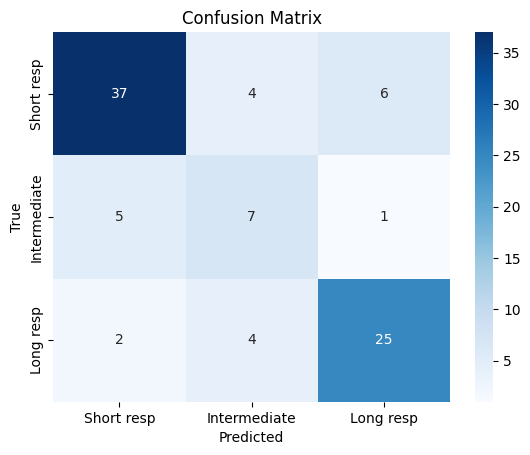

In [15]:
full_pipe.set_params(**study.best_params)

if BINARY_PFS == True:
    results = cross_validate(
        full_pipe, x, y,
        cv=skf,
        scoring=['roc_auc', 'f1'],
        return_train_score=True,
        n_jobs=-1
    )
    
    print(f"Train ROC-AUC : {results['train_roc_auc'].mean():.3f} ± {results['train_roc_auc'].std():.3f}")
    print(f"Train  F1     : {results['train_f1'].mean():.3f} ± {results['train_f1'].std():.3f}")
    print(f"Test ROC-AUC  : {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}")
    print(f"Test F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}\n")
    
    target_names = ['Short resp', 'Long resp']
else:
    results = cross_validate(
        full_pipe, x, y,
        cv=skf,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1
    )
    
    print(f"Train ROC-AUC (OVO): {results['train_roc_auc_ovo'].mean():.3f} ± {results['train_roc_auc_ovo'].std():.3f}")
    print(f"Train Macro F1     : {results['train_f1_macro'].mean():.3f} ± {results['train_f1_macro'].std():.3f}")
    print(f"Test ROC-AUC (OVO) : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
    print(f"Test Macro F1      : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}")
    
    target_names = ['Short resp', 'Intermediate', 'Long resp']

y_pred = cross_val_predict(
    full_pipe, x, y, 
    cv=skf,
    n_jobs=-1
)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [16]:
selected_per_fold = []
for tr, _ in skf.split(x, y):
    full_pipe.fit(x.iloc[tr], y.iloc[tr])
    names = full_pipe['preprocess'].get_feature_names_out()
    coefs = full_pipe['clf'].coef_[0]
    mask = coefs != 0
    selected_per_fold.append(set(names[mask]))

common = set.intersection(*selected_per_fold)
union = set.union(*selected_per_fold)
sizes = [len(s) for s in selected_per_fold]
print(f"Per-fold sizes: {sizes}")
print(f"In all folds:   {len(common)}")
print(f"Union size:     {len(union)}")
print(f"Stability ratio: {len(common) / max(1, min(sizes)):.2f}")

Per-fold sizes: [45, 45, 45, 45, 45]
In all folds:   45
Union size:     45
Stability ratio: 1.00


In [17]:
print(common)

{'remainder__NR2F1-AS1', 'remainder__CPT1C', 'remainder__MIR23B', 'drug_braf__V600E', 'categorical__AJCC_stage_IIIC', 'remainder__VMAC', 'remainder__TTYH3', 'remainder__LOC101927055', 'remainder__ANKLE2', 'categorical__LDH_normal', 'drug_braf__V600K', 'categorical__LDH_elevated', 'age__age', 'remainder__DOCK1', 'remainder__SNORD88B', 'categorical__sex_male', 'remainder__TMEM204', 'drug_braf__dabrafenib', 'categorical__sex_female', 'remainder__SMIM10', 'remainder__SLC25A26', 'remainder__LINC01152', 'remainder__COLGALT1', 'remainder__CARM1', 'remainder__SLC39A13', 'remainder__SLC36A1', 'categorical__AJCC_stage_IV', 'drug_braf__MND', 'drug_braf__cobimetinib', 'remainder__ALDH5A1', 'remainder__STX2', 'drug_braf__vemurafenib', 'remainder__CCL17', 'remainder__HRK', 'drug_braf__trametinib', 'remainder__FANCC', 'remainder__TP53TG1', 'remainder__CXCR5', 'm_stage__M_stage', 'remainder__REEP3', 'remainder__MIR27B', 'remainder__CYP4F11', 'remainder__NOTCH1', 'remainder__POU5F1B', 'remainder__ARHGA

## Explanability

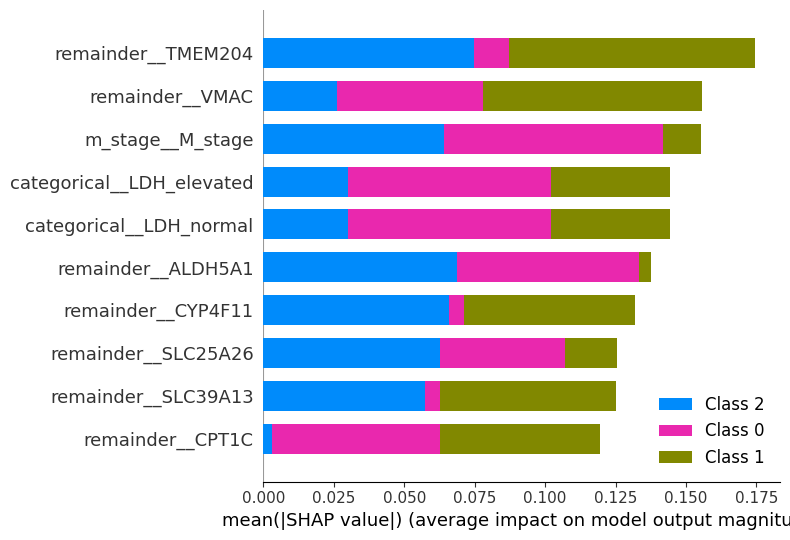

(91, 47)

In [18]:
full_pipe.fit(x, y)

x_transformed = full_pipe[:-1].transform(x)  # x -> prep -> scaler

# Recover feature names after RFE
preprocessed_feature_names = full_pipe['preprocess'].get_feature_names_out()
# selected_mask = full_pipe['selection'].support_
# feature_names = preprocessed_feature_names[selected_mask]
feature_names = preprocessed_feature_names

explainer = shap.LinearExplainer(full_pipe['clf'], x_transformed)
shap_values = explainer(x_transformed)
shap_values.feature_names = feature_names.tolist()

shap.summary_plot(shap_values, x_transformed, feature_names=feature_names, max_display=10)
x_transformed.shape


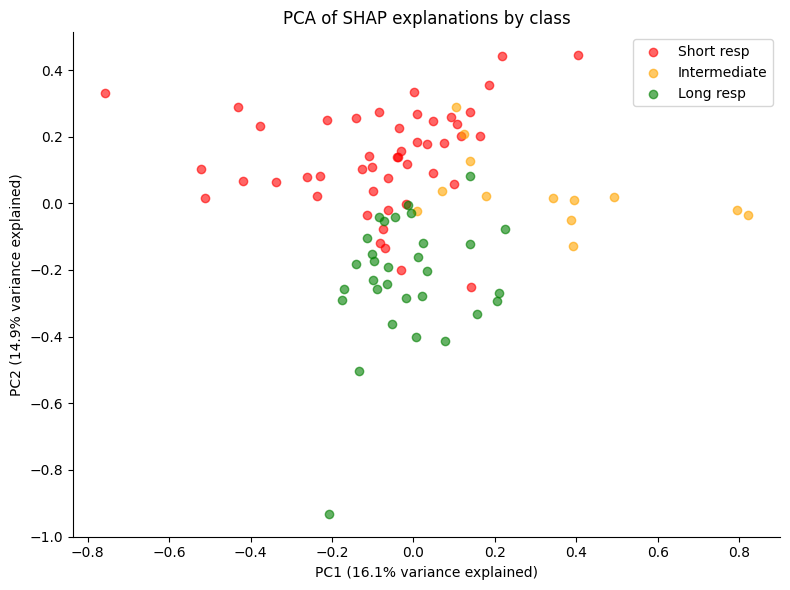

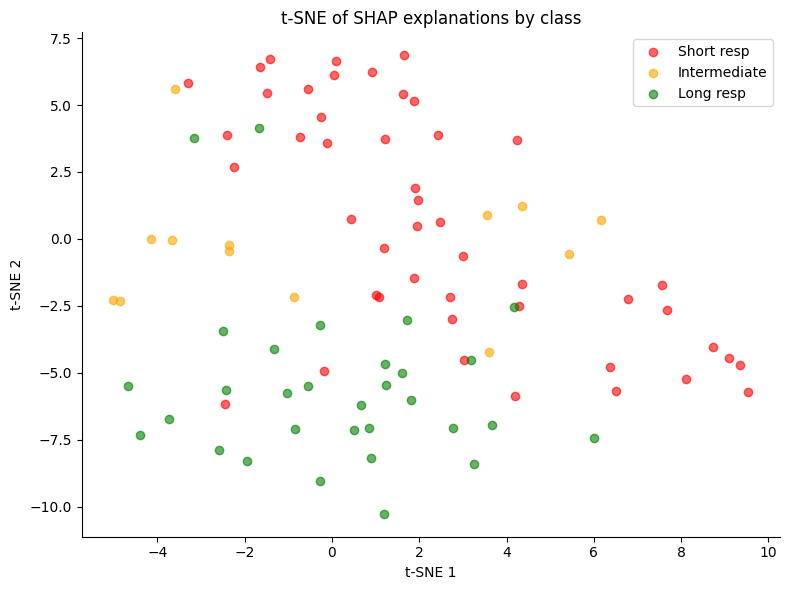

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


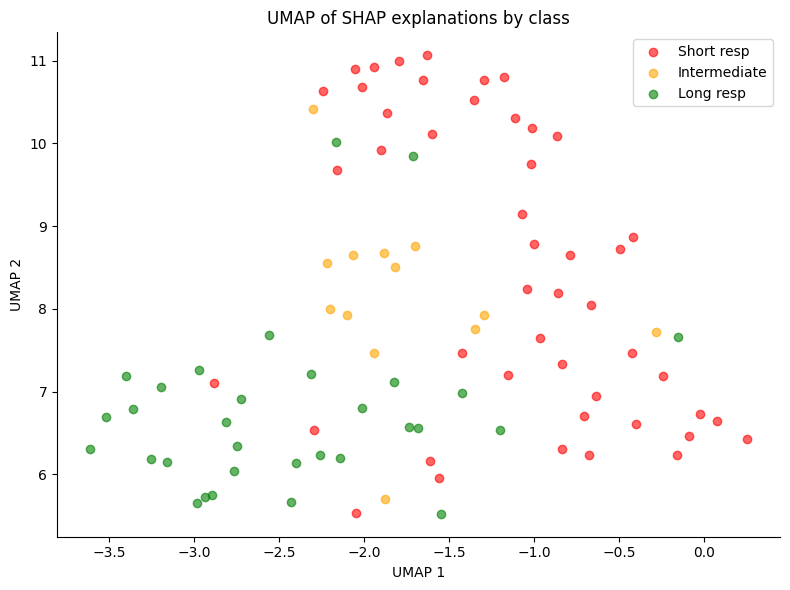

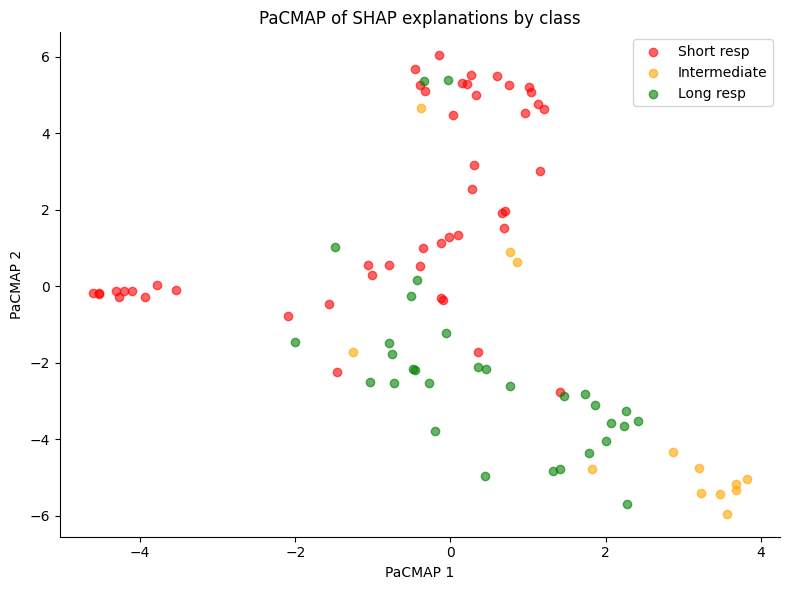

In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    if BINARY_PFS:
        colors = {0: "red", 1: "green"}
        labels = {0: "Short resp", 1: "Long resp"}
    else:
        colors = {0: "red", 1: "orange", 2: "green"}
        labels = {0: "Short resp", 1: "Intermediate", 2: "Long resp"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in sorted(colors):
        mask = y_arr == cls
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

y_arr = np.array(y)

# For multiclass SHAP, values are (n_samples, n_features, n_classes) — flatten to 2D
if BINARY_PFS:
    sv_input = shap_values.values                              # already (n_samples, n_features)
else:
    sv_input = shap_values.values.reshape(len(y_arr), -1)     # (n_samples, n_features * n_classes)

# PCA — pass explained variance
pca = PCA(n_components=2)
sv_2d = pca.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# t-SNE
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
sv_2d = tsne.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")

# UMAP
u_map = umap.UMAP(n_components=2, random_state=42)
sv_2d = u_map.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# PaCMAP
pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
sv_2d = pac_map.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")
